In [19]:
!pip install sns
import seaborn as sns

  Preparing metadata (setup.py) ... done
  Created wheel for sns: filename=sns-0.1-py3-none-any.whl size=2639 sha256=e6f238f3c19d5217f03bd4bd6a168831121cd5e1a1c5e263336135690276a294
  Stored in directory: /root/.cache/pip/wheels/26/ac/4b/7743e50a108f4a12a07e0e257dbecefc884a953125a6e1b48f
Successfully built sns


In [23]:
!pip uninstall scikit-learn -y -q
!pip install scikit-learn==1.3.2 -q
!pip install dscribe ase seaborn matplotlib pandas numpy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 82.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
spopt 0.7.0 requires scikit-learn>=1.4.0, but you have scikit-learn 1.3.2 which is incompatible.
esda 2.9.0 requires scikit-learn>=1.4, but you have scikit-learn 1.3.2 which is incompatible.
imbalanced-learn 0.14.1 requires scikit-learn<2,>=1.4.2, but you have scikit-learn 1.3.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.3.2 which is incompatible.
libpysal 4.14.1 requires scikit-learn>=1.4.0, but you have scikit-learn 1.3.2 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompa

In [20]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [21]:
#подтянем данные с гитхаба на котором они с kaggle
!git clone https://github.com/csutton7/nomad_2018_kaggle_dataset.git

import os
if os.path.exists('nomad_2018_kaggle_dataset'):
    !mv nomad_2018_kaggle_dataset/train . 2>/dev/null
    !mv nomad_2018_kaggle_dataset/test . 2>/dev/null
    !rm -rf nomad_2018_kaggle_dataset

!wget -O train.csv https://raw.githubusercontent.com/csutton7/nomad_2018_kaggle_dataset/master/train.csv
!wget -O test.csv https://raw.githubusercontent.com/csutton7/nomad_2018_kaggle_dataset/master/test.csv

Cloning into 'nomad_2018_kaggle_dataset'...
remote: Enumerating objects: 5996, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 5996 (delta 0), reused 3 (delta 0), pack-reused 5992 (from 1)
Receiving objects: 100% (5996/5996), 4.68 MiB | 10.47 MiB/s, done.
Resolving deltas: 100% (459/459), done.
--2026-05-21 22:39:29--  https://raw.githubusercontent.com/csutton7/nomad_2018_kaggle_dataset/master/train.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 218636 (214K) [text/plain]
Saving to: ‘train.csv’

train.csv           100%[===================>] 213.51K  --.-KB/s    in 0.02s   

2026-05-21 22:39:29 (11.3 MB/s) - ‘train.csv’ saved [218636/218636]

--2026-05-21 22:39:29--  https://raw.githubuserco

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.kernel_ridge import KernelRidge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_squared_log_error
from dscribe.descriptors import SOAP
from ase import Atoms
from ase.cell import Cell

In [42]:
train_csv = pd.read_csv('train.csv')
test_csv = pd.read_csv('test.csv')

print(f"Train: {len(train_csv)} samples")
print(f"Test: {len(test_csv)} samples")
print(f"Колонки: {train_csv.columns.tolist()}")

# Целевая переменная для formation energy
y_train_form = train_csv['formation_energy_ev_natom'].values

# Целевая переменная для bandgap energy
y_train_band = train_csv['bandgap_energy_ev'].values

Train: 2400 samples
Test: 600 samples
Колонки: ['id', 'spacegroup', 'number_of_total_atoms', 'percent_atom_al', 'percent_atom_ga', 'percent_atom_in', 'lattice_vector_1_ang', 'lattice_vector_2_ang', 'lattice_vector_3_ang', 'lattice_angle_alpha_degree', 'lattice_angle_beta_degree', 'lattice_angle_gamma_degree', 'formation_energy_ev_natom', 'bandgap_energy_ev']


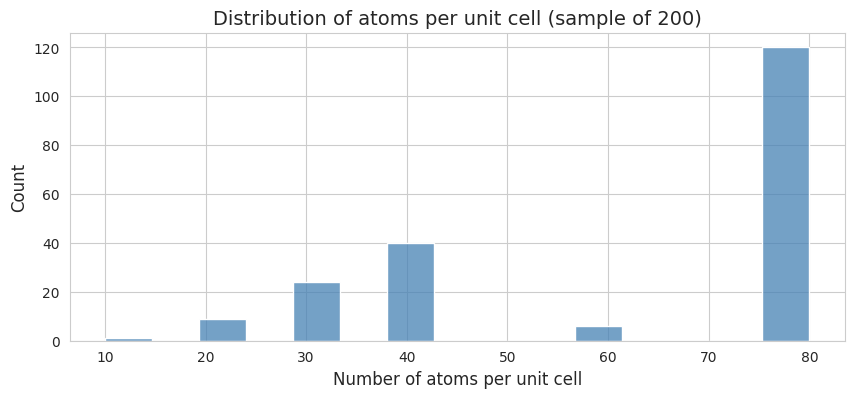

Min atoms: 10
Max atoms: 80
Mean atoms: 62.4


In [43]:
n_atoms_list = []
for idx, row in train_csv.head(200).iterrows():
    try:
        atoms = read_ase_format(f'train/{int(row["id"])}/geometry.xyz')
        n_atoms_list.append(len(atoms))
    except:
        n_atoms_list.append(0)

plt.figure(figsize=(10, 4))
sns.histplot(n_atoms_list, bins=15, kde=False, color='steelblue')
plt.xlabel('Number of atoms per unit cell', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of atoms per unit cell (sample of 200)', fontsize=14)
plt.show()

print(f"Min atoms: {min(n_atoms_list)}")
print(f"Max atoms: {max(n_atoms_list)}")
print(f"Mean atoms: {np.mean(n_atoms_list):.1f}")

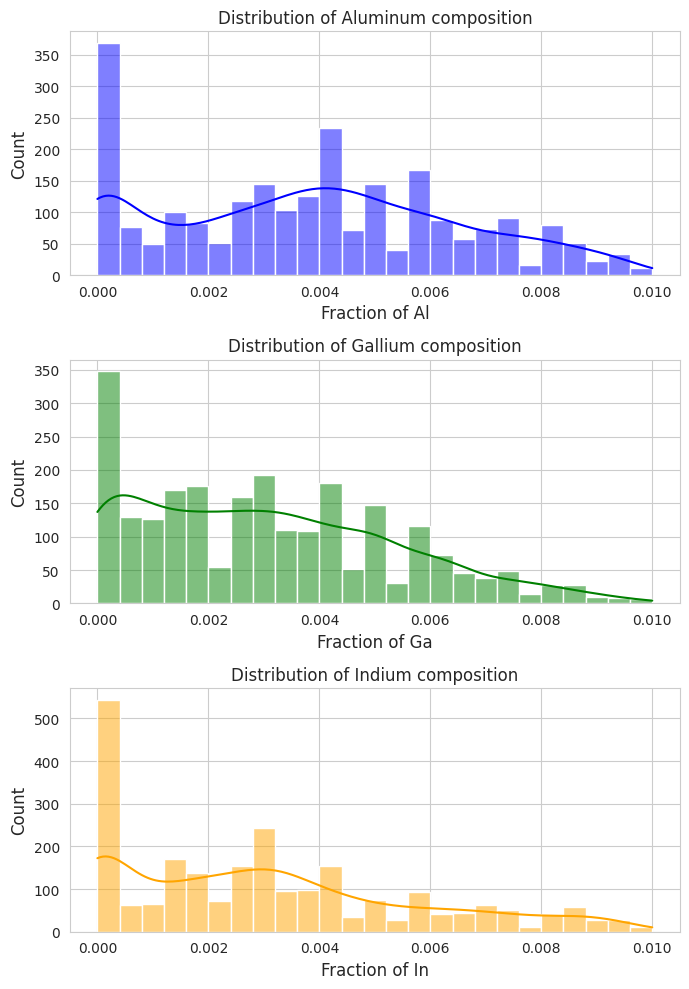

   Al: mean=0.004, std=0.003
   Ga: mean=0.003, std=0.002
   In: mean=0.003, std=0.003


In [27]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(7, 10))

compositions_al = train_csv['percent_atom_al'].values / 100
compositions_ga = train_csv['percent_atom_ga'].values / 100
compositions_in = train_csv['percent_atom_in'].values / 100

sns.histplot(compositions_al, bins=25, kde=True, ax=axs[0], color='blue')
sns.histplot(compositions_ga, bins=25, kde=True, ax=axs[1], color='green')
sns.histplot(compositions_in, bins=25, kde=True, ax=axs[2], color='orange')

axs[0].set_xlabel("Fraction of Al", fontsize=12)
axs[1].set_xlabel("Fraction of Ga", fontsize=12)
axs[2].set_xlabel("Fraction of In", fontsize=12)
axs[0].set_ylabel("Count", fontsize=12)
axs[1].set_ylabel("Count", fontsize=12)
axs[2].set_ylabel("Count", fontsize=12)

axs[0].set_title("Distribution of Aluminum composition", fontsize=12)
axs[1].set_title("Distribution of Gallium composition", fontsize=12)
axs[2].set_title("Distribution of Indium composition", fontsize=12)

plt.tight_layout()
plt.show()

print(f"   Al: mean={np.mean(compositions_al):.3f}, std={np.std(compositions_al):.3f}")
print(f"   Ga: mean={np.mean(compositions_ga):.3f}, std={np.std(compositions_ga):.3f}")
print(f"   In: mean={np.mean(compositions_in):.3f}, std={np.std(compositions_in):.3f}")

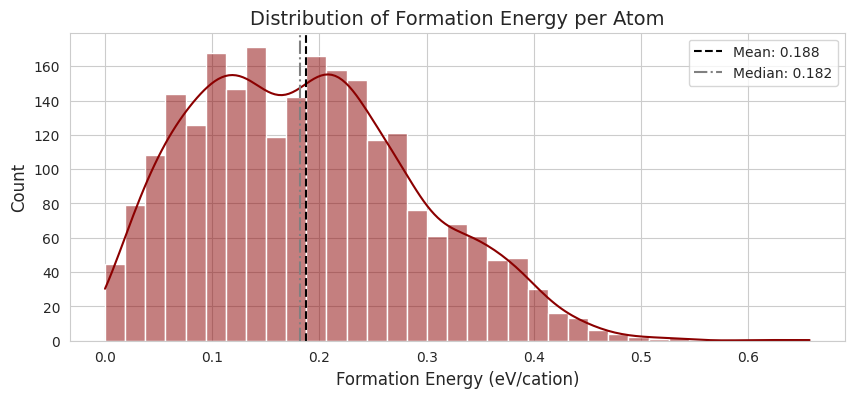

 Statistics:
Min: 0.0000
Max: 0.6572
 Mean: 0.1876
Std: 0.1041


In [28]:
fig, ax = plt.subplots(figsize=(10, 4))

sns.histplot(y_train, bins=35, kde=True, color='darkred', ax=ax)
ax.axvline(y_train.mean(), color='black', linestyle='--', label=f'Mean: {y_train.mean():.3f}')
ax.axvline(np.median(y_train), color='gray', linestyle='-.', label=f'Median: {np.median(y_train):.3f}')

ax.set_xlabel('Formation Energy (eV/cation)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of Formation Energy per Atom', fontsize=14)
ax.legend()

plt.show()

print(f" Statistics:")
print(f"Min: {y_train.min():.4f}")
print(f"Max: {y_train.max():.4f}")
print(f" Mean: {y_train.mean():.4f}")
print(f"Std: {y_train.std():.4f}")

In [30]:
spacegroups = train_csv['spacegroup'].values
unique_sg, counts = np.unique(spacegroups, return_counts=True)

print(f"   Total spacegroups: {len(unique_sg)}")
print(f"   Most common: SG {unique_sg[np.argmax(counts)]} ({max(counts)} structures)")

   Total spacegroups: 6
   Most common: SG 206 (490 structures)


In [44]:
 #функция чтения ase файлов
 def read_ase_format(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()

    lattice_vectors = []
    symbols = []
    positions = []

    for line in lines:
        line = line.strip()
        if not line or line.startswith('#'):
            continue
        parts = line.split()
        if not parts:
            continue
        if parts[0] == 'lattice_vector' and len(parts) >= 4:
            vec = [float(parts[1]), float(parts[2]), float(parts[3])]
            lattice_vectors.append(vec)
        elif parts[0] == 'atom' and len(parts) >= 5:
            x, y, z = float(parts[1]), float(parts[2]), float(parts[3])
            symbol = parts[4]
            positions.append([x, y, z])
            symbols.append(symbol)

    if lattice_vectors and len(lattice_vectors) == 3:
        cell = Cell(lattice_vectors)
        atoms = Atoms(symbols=symbols, positions=positions, cell=cell, pbc=[True, True, True])
    else:
        cell = Cell(np.eye(3) * 10.0)
        atoms = Atoms(symbols=symbols, positions=positions, cell=cell, pbc=[True, True, True])

    return atoms

In [45]:
#Настройка SOAP
soap = SOAP(
    species=["O", "Al", "Ga", "In"],
    r_cut=5.0,
    n_max=6,
    l_max=6,
    sigma=0.5,
    periodic=True
)

In [50]:
# Генерация SOAP признаков
def get_soap_features(df, folder):
    features = []
    for idx, row in df.iterrows():
        material_id = int(row['id'])
        filepath = f"{folder}/{material_id}/geometry.xyz"

        if not os.path.exists(filepath):
            features.append(np.zeros(soap.get_number_of_features()))
            continue

        try:
            atoms = read_ase_format(filepath)
            soap_desc = soap.create(atoms)
            mean_desc = soap_desc.mean(axis=0)
            features.append(mean_desc)
        except Exception as e:
            features.append(np.zeros(soap.get_number_of_features()))

    return np.array(features)

X_train_soap = get_soap_features(train_csv, 'train')
X_test_soap = get_soap_features(test_csv, 'test')

print(f"X_train shape: {X_train_soap.shape}")
print(f"X_test shape: {X_test_soap.shape}")

X_train shape: (2400, 2100)
X_test shape: (600, 2100)


In [51]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_soap)
X_test_scaled = scaler.transform(X_test_soap)

y_train_log = np.log1p(y_train)
#признаки должны быть в одном масштабе, чтобы KRR работал корректно

In [35]:
#поиск оптимальных параметров крр
param_grid = {
    'alpha': [0.001, 0.0005, 0.0001, 0.00005, 0.00001],
    'gamma': [0.0001, 0.00005, 0.00001, 0.000005, 0.000001]
}

krr = KernelRidge(kernel='rbf')
kf = KFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    krr, param_grid, cv=kf,
    scoring='neg_mean_squared_error',
    n_jobs=1,
    verbose=1
)
grid_search.fit(X_train_scaled, y_train_log)

print(f"Best params: {grid_search.best_params_}")
best_krr = grid_search.best_estimator_

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best params: {'alpha': 1e-05, 'gamma': 1e-06}


In [36]:
# Предсказание на тесте
pred_form = np.expm1(best_krr.predict(X_test_scaled))
pred_form = np.maximum(pred_form, 1e-8)

# Оценка на тренировке
train_pred = np.expm1(best_krr.predict(X_train_scaled))
train_rmsle = np.sqrt(mean_squared_log_error(y_train, train_pred))
print(f"Training RMSLE: {train_rmsle:.5f}")

Training RMSLE: 0.01474


In [37]:
y_train_band = train_csv['bandgap_energy_ev'].values
y_train_band_log = np.log1p(y_train_band)

krr_band = KernelRidge(kernel='rbf', alpha=0.001, gamma=0.00001)
krr_band.fit(X_train_scaled, y_train_band_log)

pred_band = np.expm1(krr_band.predict(X_test_scaled))
pred_band = np.maximum(pred_band, 0.01)
train_pred_band = np.expm1(krr_band.predict(X_train_scaled))
rmsle_band = np.sqrt(mean_squared_log_error(y_train_band, train_pred_band))


In [38]:
submission = pd.DataFrame({
    'id': test_csv['id'],
    'formation_energy_ev_natom': pred_form,
    'bandgap_energy_ev': pred_band
})

submission.to_csv('submission_final.csv', index=False)

print(f"   Formation predictions: [{pred_form.min():.4f}, {pred_form.max():.4f}]")
print(f"   Bandgap predictions:   [{pred_band.min():.4f}, {pred_band.max():.4f}]")

from google.colab import files
files.download('submission_final.csv')

   Formation predictions: [0.0000, 0.5746]
   Bandgap predictions:   [0.1971, 5.6493]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

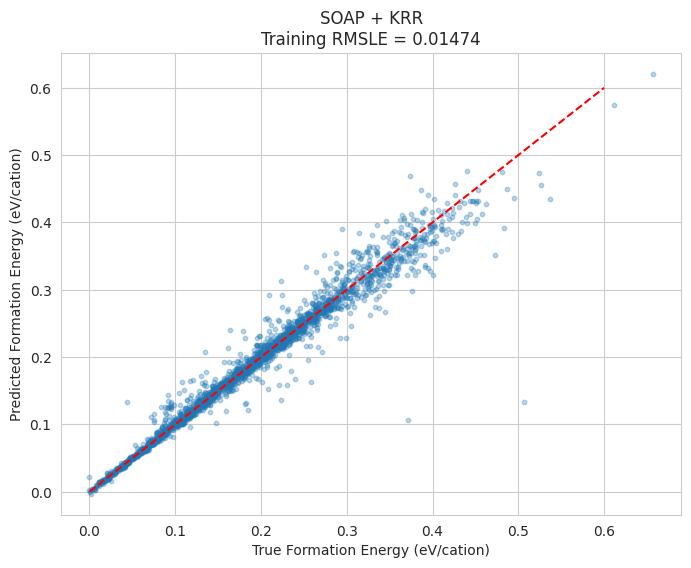

   Residuals: mean=-0.00018, std=0.01882
   95% of residuals between: -0.0375 and 0.0359


In [39]:
plt.figure(figsize=(8, 6))
plt.scatter(y_train, train_pred, alpha=0.3, s=10)
plt.plot([0, 0.6], [0, 0.6], 'r--')
plt.xlabel('True Formation Energy (eV/cation)')
plt.ylabel('Predicted Formation Energy (eV/cation)')
plt.title(f'SOAP + KRR\nTraining RMSLE = {train_rmsle:.5f}')
plt.show()

residuals = train_pred - y_train
print(f"   Residuals: mean={residuals.mean():.5f}, std={residuals.std():.5f}")
print(f"   95% of residuals between: {np.percentile(residuals, 2.5):.4f} and {np.percentile(residuals, 97.5):.4f}")


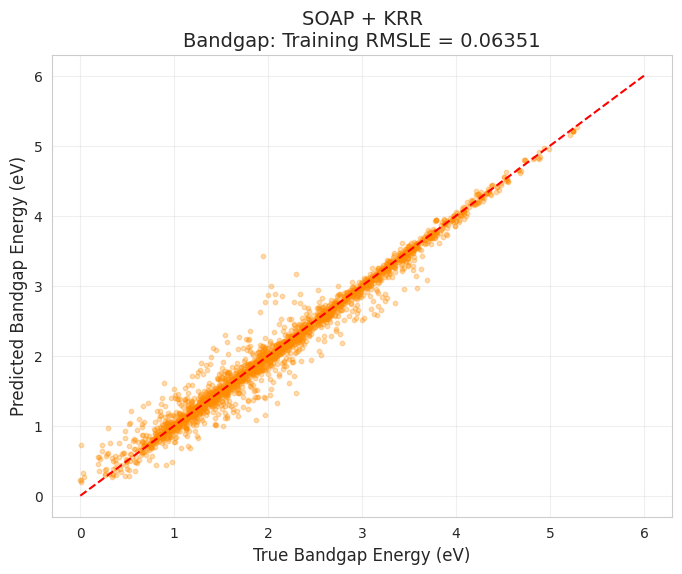

Bandgap Training RMSLE: 0.06351


In [40]:
y_train_band = train_csv['bandgap_energy_ev'].values

# Обучаем KRR для bandgap (те же параметры, что для formation)
krr_band = KernelRidge(kernel='rbf', alpha=0.001, gamma=0.00001)
krr_band.fit(X_train_scaled, np.log1p(y_train_band))

train_pred_band = np.expm1(krr_band.predict(X_train_scaled))
rmsle_band = np.sqrt(mean_squared_log_error(y_train_band, train_pred_band))

plt.figure(figsize=(8, 6))
plt.scatter(y_train_band, train_pred_band, alpha=0.3, s=10, color='darkorange')
plt.plot([0, 6], [0, 6], 'r--')  # bandgap обычно до 5-6 eV
plt.xlabel('True Bandgap Energy (eV)', fontsize=12)
plt.ylabel('Predicted Bandgap Energy (eV)', fontsize=12)
plt.title(f'SOAP + KRR\nBandgap: Training RMSLE = {rmsle_band:.5f}', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

print(f"Bandgap Training RMSLE: {rmsle_band:.5f}")